<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Glass_and_Metals_with_Similar_Melting_Points.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

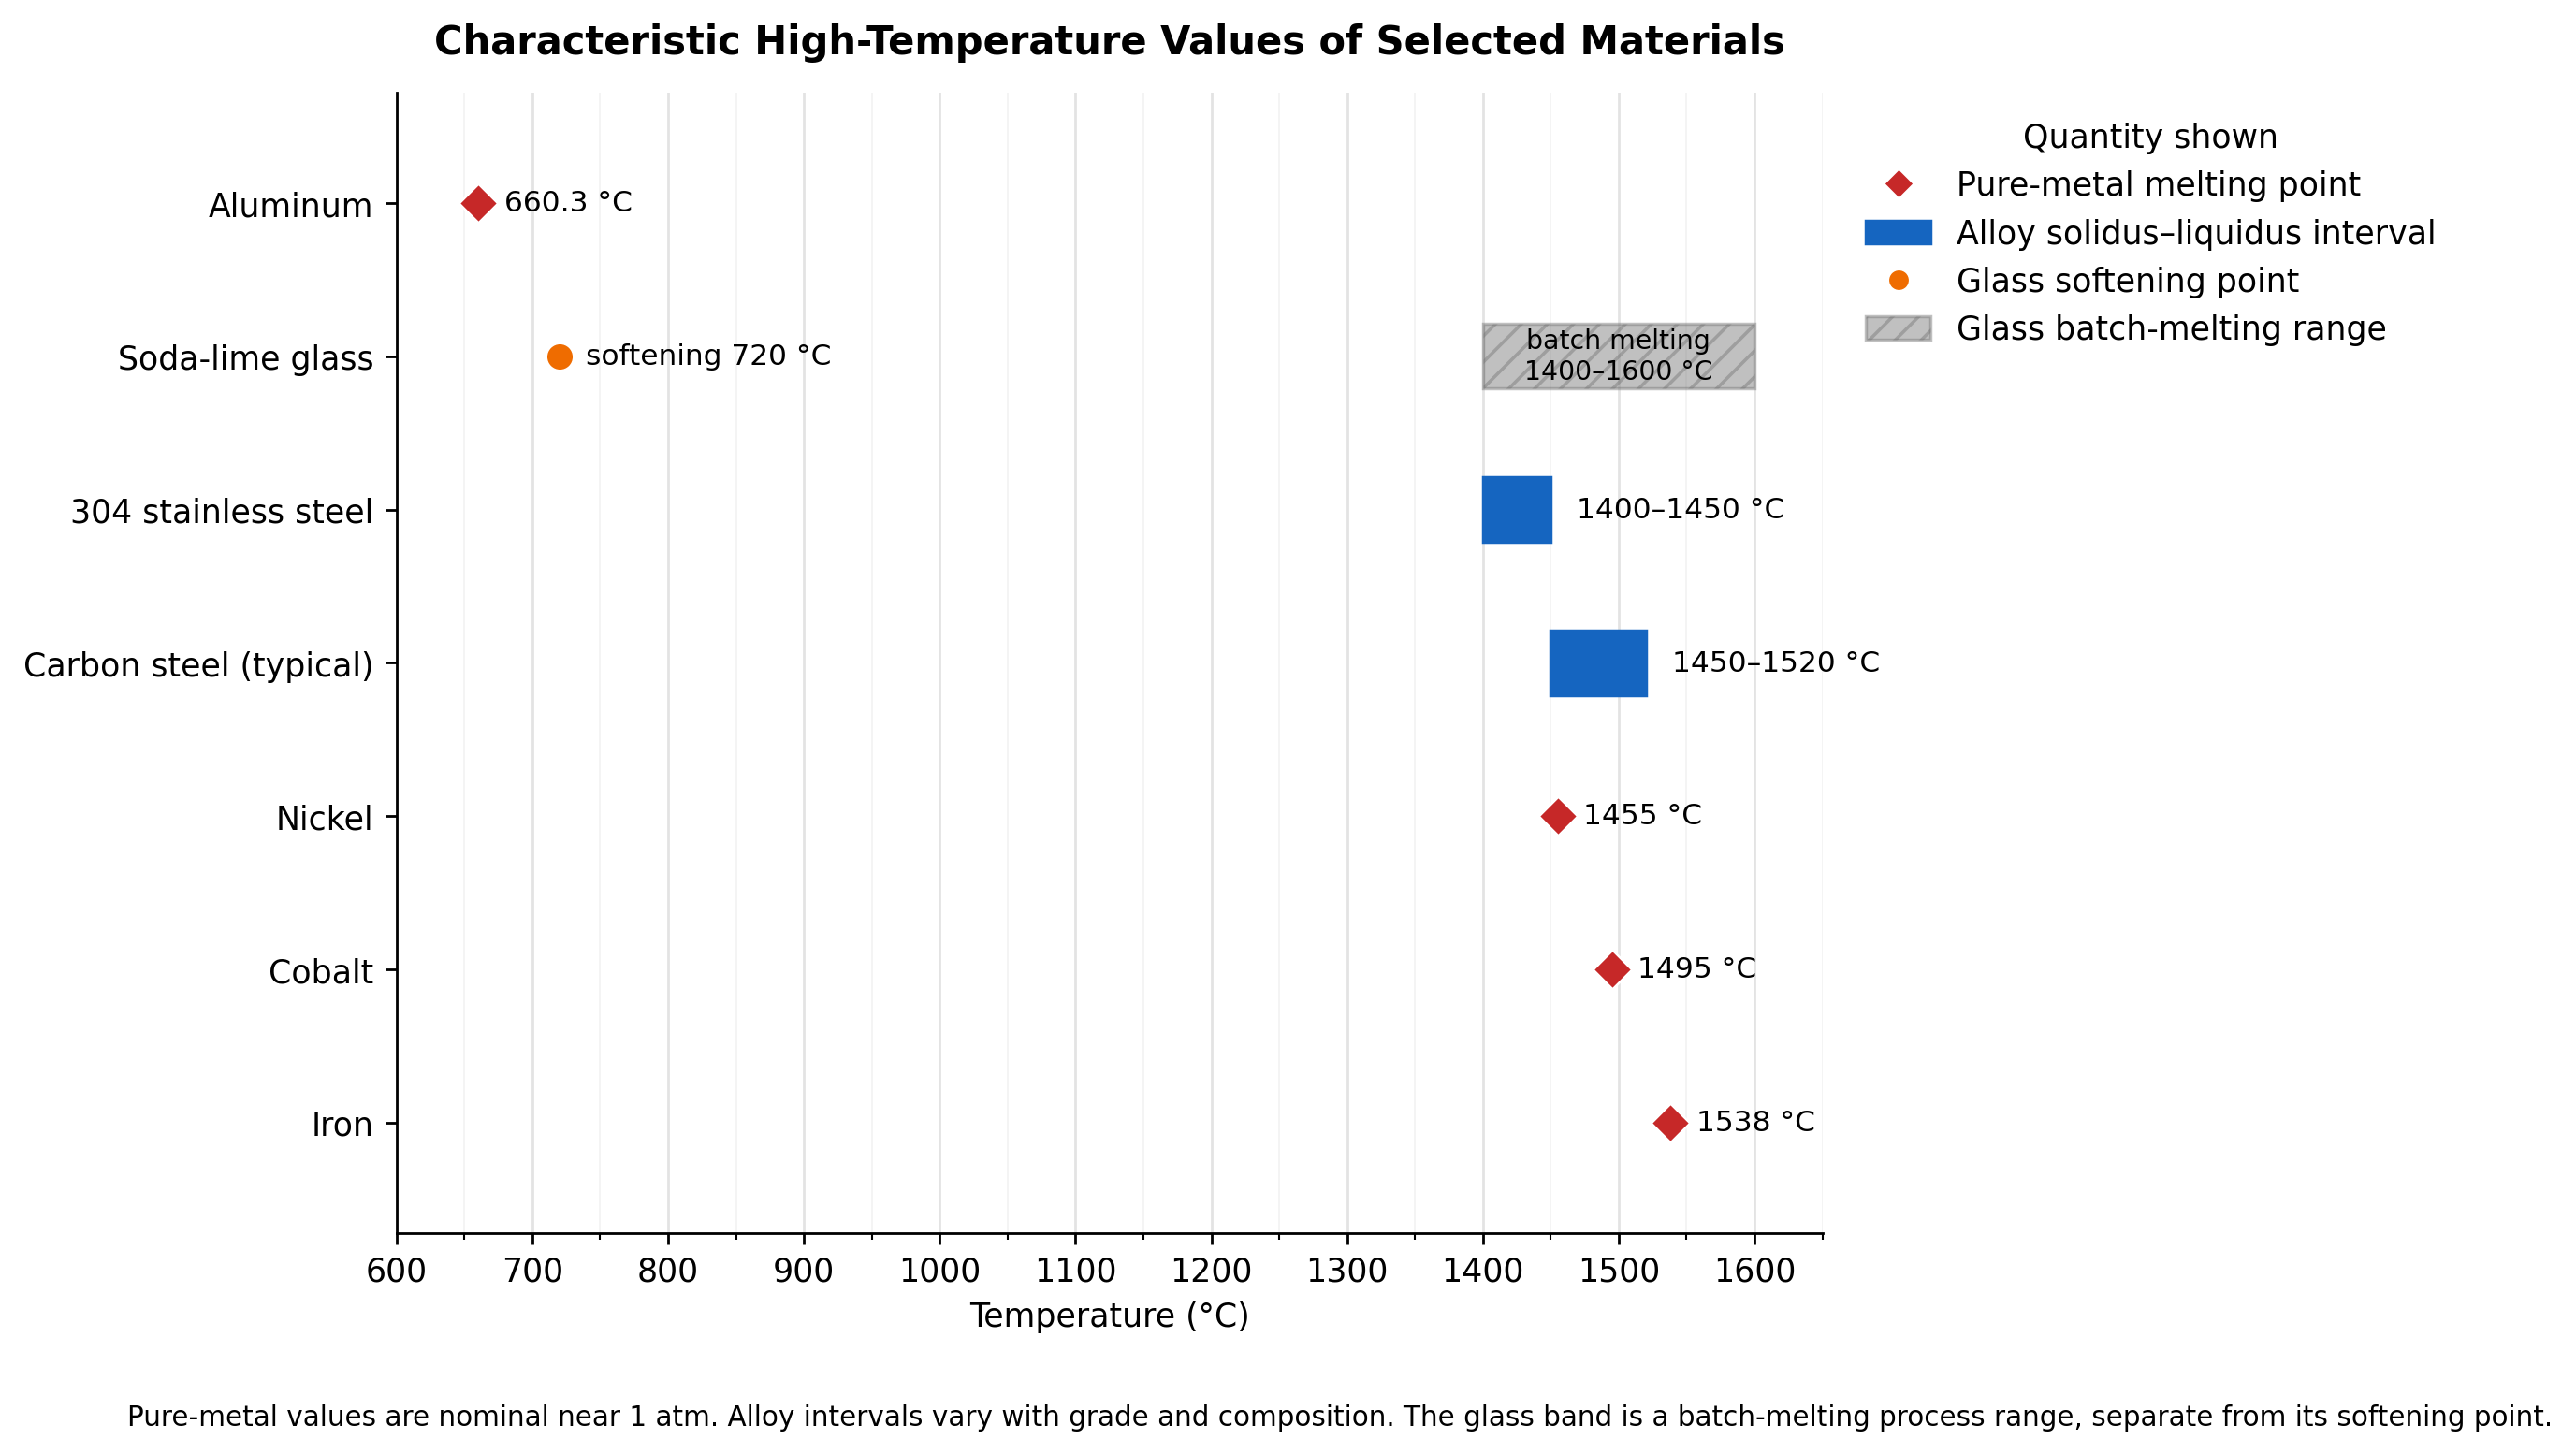

In [ ]:
"""Plots characteristic high-temperature values for selected materials."""

from dataclasses import dataclass
from enum import Enum

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator


# Control knobs
PLOT_DPI: int = 250
FIGURE_SIZE_IN: tuple[float, float] = (11.5, 6.5)
X_LIMITS_C: tuple[float, float] = (600.0, 1650.0)
MAJOR_TICK_INTERVAL_C: float = 100.0
MINOR_TICK_INTERVAL_C: float = 50.0
BAR_HEIGHT: float = 0.42
POINT_SIZE: float = 72.0

PURE_METAL_COLOR: str = "#C62828"
ALLOY_RANGE_COLOR: str = "#1565C0"
GLASS_SOFTENING_COLOR: str = "#EF6C00"
GLASS_PROCESS_COLOR: str = "#757575"

SODA_LIME_SOFTENING_TEMP_C: float = 720.0
SODA_LIME_BATCH_MIN_C: float = 1400.0
SODA_LIME_BATCH_MAX_C: float = 1600.0

X_AXIS_LABEL: str = "Temperature (°C)"
PLOT_TITLE: str = (
    "Characteristic High-Temperature Values of Selected Materials"
)
PLOT_NOTE: str = (
    "Pure-metal values are nominal near 1 atm. Alloy intervals vary "
    "with grade and composition. The glass band is a batch-melting "
    "process range, separate from its softening point."
)


class DatumKind(Enum):
    """Identifies the physical meaning and visual form of a datum."""

    PURE_METAL = "pure_metal"
    ALLOY_INTERVAL = "alloy_interval"
    GLASS_PROCESS = "glass_process"


@dataclass(frozen=True)
class MaterialDatum:
    """Stores one material temperature datum.

    Attributes:
        label: Material name displayed on the vertical axis.
        lower_c: Point temperature or lower interval bound in Celsius.
        upper_c: Upper interval bound in Celsius, where applicable.
        kind: Physical category used to select the plotting method.
        marker_c: Optional secondary point temperature in Celsius.
    """

    label: str
    lower_c: float
    upper_c: float | None
    kind: DatumKind
    marker_c: float | None = None


MATERIAL_DATA: tuple[MaterialDatum, ...] = (
    MaterialDatum(
        label="Aluminum",
        lower_c=660.3,
        upper_c=None,
        kind=DatumKind.PURE_METAL,
    ),
    MaterialDatum(
        label="Soda-lime glass",
        lower_c=SODA_LIME_BATCH_MIN_C,
        upper_c=SODA_LIME_BATCH_MAX_C,
        kind=DatumKind.GLASS_PROCESS,
        marker_c=SODA_LIME_SOFTENING_TEMP_C,
    ),
    MaterialDatum(
        label="304 stainless steel",
        lower_c=1400.0,
        upper_c=1450.0,
        kind=DatumKind.ALLOY_INTERVAL,
    ),
    MaterialDatum(
        label="Carbon steel (typical)",
        lower_c=1450.0,
        upper_c=1520.0,
        kind=DatumKind.ALLOY_INTERVAL,
    ),
    MaterialDatum(
        label="Nickel",
        lower_c=1455.0,
        upper_c=None,
        kind=DatumKind.PURE_METAL,
    ),
    MaterialDatum(
        label="Cobalt",
        lower_c=1495.0,
        upper_c=None,
        kind=DatumKind.PURE_METAL,
    ),
    MaterialDatum(
        label="Iron",
        lower_c=1538.0,
        upper_c=None,
        kind=DatumKind.PURE_METAL,
    ),
)


def _configure_plot_style() -> None:
    """Applies shared Matplotlib typography and rendering settings."""
    plt.rcParams.update(
        {
            "figure.dpi": PLOT_DPI,
            "font.family": "sans-serif",
            "font.sans-serif": ["Tahoma", "DejaVu Sans"],
            "font.weight": "normal",
            "axes.titleweight": "semibold",
        }
    )


def _draw_datum(
    axes: Axes,
    datum: MaterialDatum,
    y_position: int,
) -> None:
    """Draws one point, interval, or glass-processing datum."""
    if datum.kind is DatumKind.PURE_METAL:
        axes.scatter(
            datum.lower_c,
            y_position,
            marker="D",
            s=POINT_SIZE,
            color=PURE_METAL_COLOR,
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )
        axes.annotate(
            f"{datum.lower_c:g} °C",
            xy=(datum.lower_c, y_position),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
        )
        return

    if datum.upper_c is None:
        raise ValueError(f"Missing upper bound for {datum.label}.")

    interval_width = datum.upper_c - datum.lower_c
    if interval_width <= 0.0:
        raise ValueError(f"Invalid interval for {datum.label}.")

    if datum.kind is DatumKind.ALLOY_INTERVAL:
        axes.barh(
            y_position,
            interval_width,
            left=datum.lower_c,
            height=BAR_HEIGHT,
            color=ALLOY_RANGE_COLOR,
            edgecolor=ALLOY_RANGE_COLOR,
            zorder=2,
        )
        axes.annotate(
            f"{datum.lower_c:g}–{datum.upper_c:g} °C",
            xy=(datum.upper_c, y_position),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
        )
        return

    axes.barh(
        y_position,
        interval_width,
        left=datum.lower_c,
        height=BAR_HEIGHT,
        color=GLASS_PROCESS_COLOR,
        edgecolor=GLASS_PROCESS_COLOR,
        hatch="///",
        alpha=0.45,
        zorder=2,
    )
    axes.text(
        datum.lower_c + interval_width / 2.0,
        y_position,
        f"batch melting\n{datum.lower_c:g}–{datum.upper_c:g} °C",
        ha="center",
        va="center",
        fontsize=8.2,
    )

    if datum.marker_c is None:
        raise ValueError(f"Missing softening point for {datum.label}.")

    axes.scatter(
        datum.marker_c,
        y_position,
        marker="o",
        s=POINT_SIZE,
        color=GLASS_SOFTENING_COLOR,
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )
    axes.annotate(
        f"softening {datum.marker_c:g} °C",
        xy=(datum.marker_c, y_position),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )


def _build_legend() -> list[Line2D | Patch]:
    """Builds legend handles for each physical quantity."""
    return [
        Line2D(
            [],
            [],
            marker="D",
            linestyle="",
            markersize=7,
            markerfacecolor=PURE_METAL_COLOR,
            markeredgecolor="white",
            label="Pure-metal melting point",
        ),
        Patch(
            facecolor=ALLOY_RANGE_COLOR,
            edgecolor=ALLOY_RANGE_COLOR,
            label="Alloy solidus–liquidus interval",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="",
            markersize=7,
            markerfacecolor=GLASS_SOFTENING_COLOR,
            markeredgecolor="white",
            label="Glass softening point",
        ),
        Patch(
            facecolor=GLASS_PROCESS_COLOR,
            edgecolor=GLASS_PROCESS_COLOR,
            hatch="///",
            alpha=0.45,
            label="Glass batch-melting range",
        ),
    ]


def generate_temperature_plot() -> None:
    """Renders the corrected material-temperature comparison plot."""
    _configure_plot_style()

    figure, axes = plt.subplots(figsize=FIGURE_SIZE_IN)
    y_positions = range(len(MATERIAL_DATA))

    for y_position, datum in zip(
        y_positions,
        MATERIAL_DATA,
        strict=True,
    ):
        _draw_datum(axes, datum, y_position)

    axes.set_yticks(list(y_positions))
    axes.set_yticklabels(
        [datum.label for datum in MATERIAL_DATA]
    )
    axes.invert_yaxis()

    axes.set_xlim(*X_LIMITS_C)
    axes.set_xlabel(X_AXIS_LABEL)
    axes.set_title(PLOT_TITLE, pad=12)

    axes.xaxis.set_major_locator(
        MultipleLocator(MAJOR_TICK_INTERVAL_C)
    )
    axes.xaxis.set_minor_locator(
        MultipleLocator(MINOR_TICK_INTERVAL_C)
    )

    axes.set_axisbelow(True)
    axes.grid(
        axis="x",
        which="major",
        linewidth=0.8,
        alpha=0.35,
    )
    axes.grid(
        axis="x",
        which="minor",
        linewidth=0.5,
        alpha=0.15,
    )

    axes.spines["top"].set_visible(False)
    axes.spines["right"].set_visible(False)
    axes.margins(y=0.12)

    axes.legend(
        handles=_build_legend(),
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=False,
        title="Quantity shown",
    )

    figure.text(
        0.10,
        0.02,
        PLOT_NOTE,
        ha="left",
        va="bottom",
        fontsize=8.5,
    )
    figure.subplots_adjust(
        left=0.20,
        right=0.73,
        bottom=0.15,
        top=0.90,
    )

    plt.show()


if __name__ == "__main__":
    generate_temperature_plot()